In [10]:
import os
import numpy as np
import galsim
from galsim import roman
from romanisim import image, parameters, catalog, util, wcs
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import table
import asdf
from romanisim import log
import romanisim.bandpass
from scipy.ndimage import gaussian_filter
from astropy.io import fits
import matplotlib.pyplot as plt
from glob import glob
from matplotlib.colors import LogNorm
import romanisim
romanisim.__version__

import mejiro
from mejiro.galaxy_galaxy import Sample1, Sample2, SampleGG
from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.style import set_aas_style
set_aas_style()

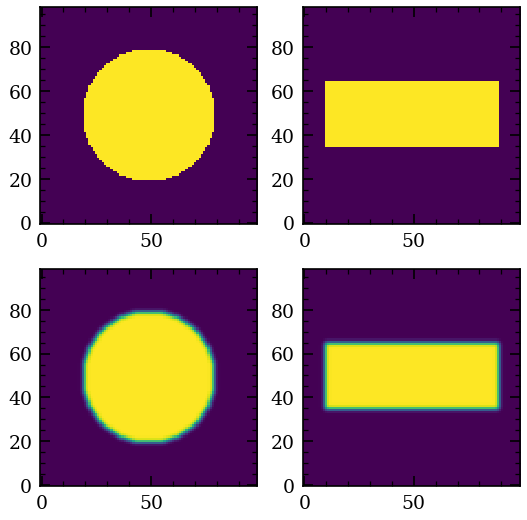

In [ ]:
# make some simple example images
imsz = 99
cenpix = imsz // 2
yy, xx = np.meshgrid(np.arange(imsz) - cenpix, np.arange(imsz) - cenpix)
im1 = ((xx ** 2 + yy ** 2) < 30 ** 2) * 1.0  # circle
im2 = im1 * 0
im2[35:65, 10:-10] = 1  # rectangle

sigma = 1

_, ax = plt.subplots(2, 2)
ax[0, 0].imshow(im1, origin='lower')
ax[0, 1].imshow(im2, origin='lower')
ax[1, 0].imshow(gaussian_filter(im1, sigma), origin='lower')
ax[1, 1].imshow(gaussian_filter(im2, sigma), origin='lower')
plt.show()

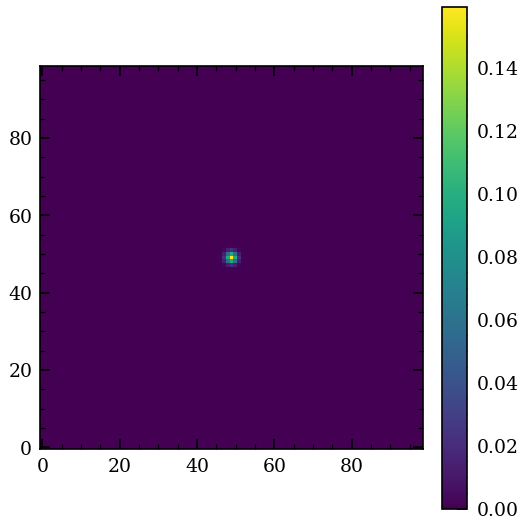

In [ ]:
# make a PSF for these
psf = im1 * 0
psf[cenpix, cenpix] = 1
from scipy.ndimage import gaussian_filter
psf = gaussian_filter(psf, sigma)

plt.imshow(psf, origin='lower')
plt.colorbar()
plt.show()

In [59]:
# set up the image catalog
from astropy.io import fits
filenames = ['im1.fits', 'im2.fits']
fits.writeto(filenames[0], gaussian_filter(im1, sigma), overwrite=True)
fits.writeto(filenames[1], gaussian_filter(im2, sigma), overwrite=True)
base_rgc_filename = 'test_image_catalog'
catalog_filename = base_rgc_filename + '.fits'
catalog_img_filename = base_rgc_filename + '_img.fits'
catalog_psf_filename = base_rgc_filename + '_psf.fits'
catalog_files = [catalog_filename, catalog_img_filename, catalog_psf_filename]
_ = [os.remove(f) for f in catalog_files if os.path.exists(f)]
catalog.make_image_catalog(filenames, psf, base_rgc_filename)

# make some metadata to describe an image for us to render
roman.n_pix = 4088
coord = SkyCoord(270 * u.deg, 66 * u.deg)
meta = util.default_image_meta(coord=coord, filter_name='F087')
wcs.fill_in_parameters(meta, coord, boresight=False)
imwcs = wcs.get_wcs(meta, usecrds=False)

# make a table of sources for us to render
tab = table.Table()
cen = imwcs.toWorld(galsim.PositionD(roman.n_pix / 2, roman.n_pix / 2))
offsets = np.array([[0], [0]])
offsets = offsets * 0.11 / 60 / 60
tab['ra'] = util.skycoord(cen).ra.to(u.degree).value + offsets[0, :]
tab['dec'] = util.skycoord(cen).dec.to(u.degree).value + offsets[1, :]
tab['ident'] = [1]  # alternate circles and rectangles
tab['rotate'] = [120]
tab['shear_pa'] = [0]
tab['shear_ba'] = [1]
tab['dilate'] = [1.]
tab['F087'] = [2e-7]
tab.meta['real_galaxy_catalog_filename'] = str(base_rgc_filename) + '.fits'

In [60]:
# render the image
res = image.simulate(meta, tab, usecrds=False, psftype='galsim')

2026-03-06 11:43:58 WARNING  --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-03-06 11:43:58 WARNING  No RNG set, constructing a new default RNG from default seed.
2026-03-06 11:43:58 INFO     Simulating filter F087...
2026-03-06 11:43:58 INFO     Creating PSF using galsim
2026-03-06 11:43:59 INFO     Creating PSF using galsim
2026-03-06 11:43:59 INFO     Creating PSF using galsim
2026-03-06 11:43:59 INFO     Creating PSF using galsim
2026-03-06 11:44:01 INFO     Adding 1 sources to image...
2026-03-06 11:44:01 WARNING  You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-03-06 11:44:01 INFO     Rendered 0 point sources in 0.00823 seconds
2026-03-06 11:44:01 INFO     Rendered 1 total sources in 0.113 seconds
2026-03-06 11:44:03 INFO     Apportioning electrons to resultants...
/data/bwedig/.conda/

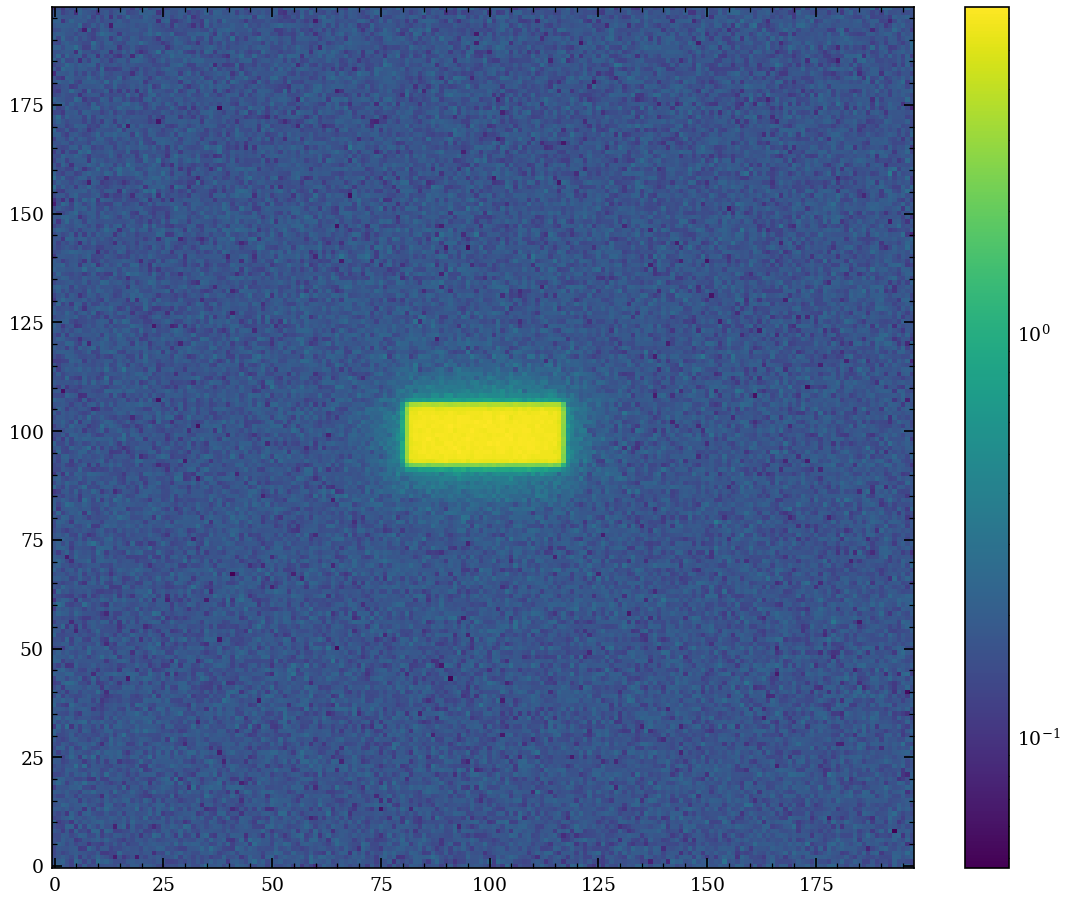

In [61]:
plt.figure(figsize=(8, 6))
plt.imshow(res[0].data[roman.n_pix // 2 - 99:roman.n_pix // 2 + 99, roman.n_pix // 2 - 99:roman.n_pix // 2 + 99], norm=LogNorm())
plt.colorbar()
plt.show()

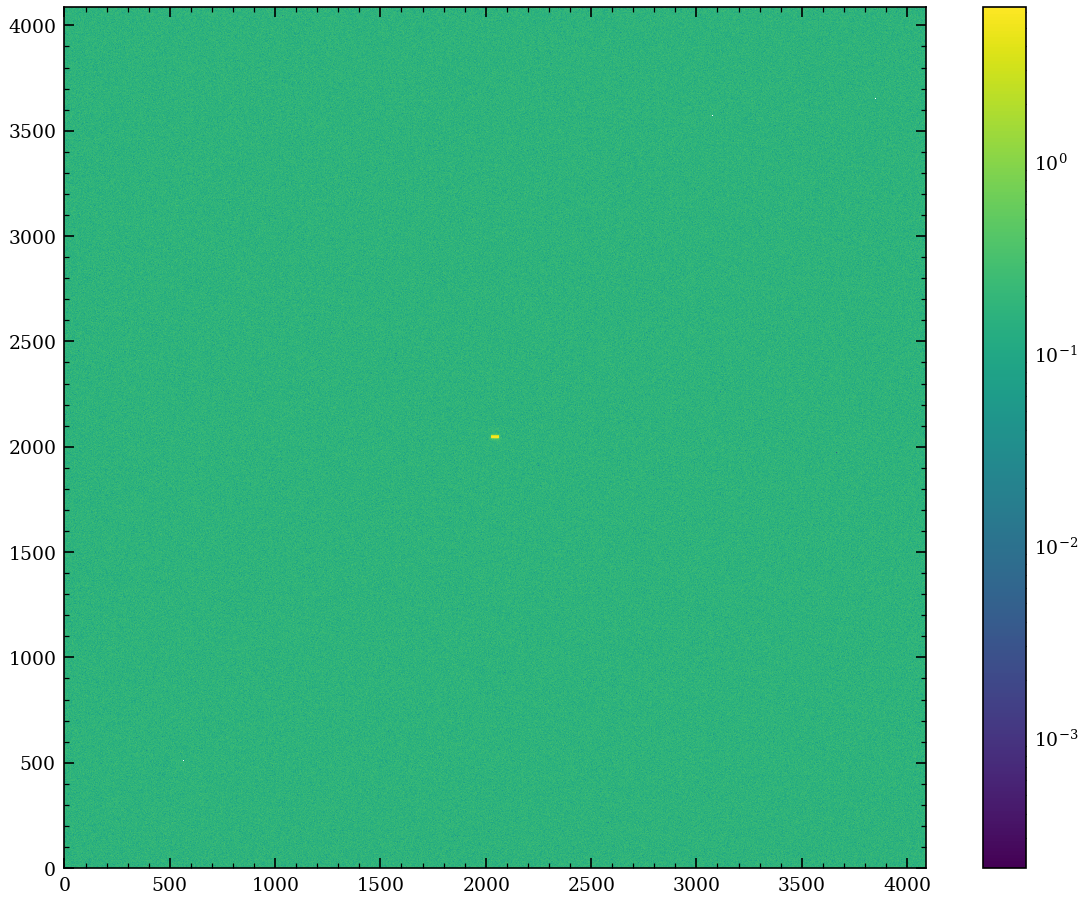

In [62]:
plt.figure(figsize=(8, 6))
plt.imshow(res[0].data, norm=LogNorm())
plt.colorbar()
plt.show()